## 🏠 House Price Prediction with Multiple Linear Regression and Pipeline

.In this project, house prices are predicted using Multiple Linear Regression. A Pipeline is also used to organize the preprocessing and model training steps, and its performance is evaluated.


In this section, the required libraries for data handling, numerical computations, and visualization are imported.


In [1]:
import numpy as np
import pandas as pd
import pylab as pl
import matplotlib.pyplot as plt

## 📌 Dataset Overview


Before building any machine learning model, it's important to understand the dataset.

This dataset contains information about residential properties in Tehran. Each row represents a single house, while the columns describe different features such as the area, number of rooms, parking, warehouse, elevator, address, and the house price in USD.

The main goal of this project is to use these features to build a machine learning model that can predict house prices.

## the dataset is included in this repository, so you can download it and follow the notebook step by step without any additional setup

## 📌 Load the Dataset

In this step, I load the dataset into a pandas DataFrame so I can start working with it. After loading the file, I display the DataFrame to make sure it has been imported correctly and to get a quick look at the overall structure of the data.

In [2]:
df = pd.read_csv('Houseprice.csv')
df

,Area,Room,Parking,Warehouse,Elevator,Address,Price,Price(USD)
0,63,1,True,True,True,Shahran,1.850000e+09,61666.67
1,60,1,True,True,True,Shahran,1.850000e+09,61666.67
2,79,2,True,True,True,Pardis,5.500000e+08,18333.33
3,95,2,True,True,True,Shahrake Qods,9.025000e+08,30083.33
4,123,2,True,True,True,Shahrake Gharb,7.000000e+09,233333.33
...,...,...,...,...,...,...,...,...
3474,86,2,True,True,True,Southern Janatabad,3.500000e+09,116666.67
3475,83,2,True,True,True,Niavaran,6.800000e+09,226666.67
3476,75,2,False,False,False,Parand,3.650000e+08,12166.67
3477,105,2,True,True,True,Dorous,5.600000e+09,186666.67


In [3]:
print(df['Address'].isnull().sum())
print(df.shape)

23
(3479, 8)


## 📌 Handle Missing Values


Before moving forward, I remove the rows where the **Address** value is missing.

Since the address is one of the most important features in this project, records without this information cannot be used effectively for analysis or model training.

In [4]:
df.dropna(subset=['Address'], inplace=True)

In [26]:
print(df['Area'].dtype)

str


## 📌 Clean and Convert the Area Feature

In this step, I prepare the **Area** column for machine learning.

First, I remove the thousands separators (`,`), then convert the values into a numeric data type. Any invalid values that cannot be converted are treated as missing values and removed to keep the dataset clean and ready for analysis.

In [6]:
df['Area'] = df['Area'].str.replace(',','',regex=False)
df['Area'] = pd.to_numeric(df['Area'],errors='coerce')
df.dropna(subset=['Area'], inplace=True)

## 📌 Remove Extreme Outliers


In this step, I remove properties with an area larger than **1000 square meters**.

These observations are very rare and can behave as outliers, which may negatively affect the performance of a Linear Regression model. Removing them helps the model focus on the overall pattern of the housing market.

In [7]:
df = df[df['Area'] < 1000]
print(df.shape)

(3450, 8)


## 📌 Remove Duplicate Records


In this step, I remove duplicate records from the dataset.

Duplicate entries can give some observations more influence than others, which may introduce bias during model training. Removing them ensures that each property is represented only once in the dataset.

In [8]:
df.drop_duplicates(inplace=True)

## 📌 Explore the Dataset


Before moving on to data analysis and model building, I perform a quick overview of the dataset.

In this section, I inspect the dataset structure, verify the data types, check for missing values, and review the basic statistical summary of the numerical features. This gives me a better understanding of the data and confirms that it is ready for the next steps.

In [9]:
df.info()
df.isnull().sum()
df.describe()

<class 'pandas.DataFrame'>
Index: 3242 entries, 0 to 3478
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Area        3242 non-null   int64  
 1   Room        3242 non-null   int64  
 2   Parking     3242 non-null   bool   
 3   Warehouse   3242 non-null   bool   
 4   Elevator    3242 non-null   bool   
 5   Address     3242 non-null   str    
 6   Price       3242 non-null   float64
 7   Price(USD)  3242 non-null   float64
dtypes: bool(3), float64(2), int64(2), str(1)
memory usage: 161.5 KB


,Area,Room,Price,Price(USD)
count,3242.000000,3242.000000,3.242000e+03,3.242000e+03
mean,107.701110,2.087909,5.473623e+09,1.824541e+05
std,70.935755,0.765248,8.272617e+09,2.757539e+05
min,30.000000,0.000000,3.600000e+06,1.200000e+02
25%,70.000000,2.000000,1.420000e+09,4.733333e+04
50%,90.000000,2.000000,2.970000e+09,9.900000e+04
75%,121.000000,2.000000,6.157500e+09,2.052500e+05
max,929.000000,5.000000,9.240000e+10,3.080000e+06


# 📌 Preparing Data for Modeling

## 📌 Select Features and Target


In this step, I define the input features (**X**) and the target variable (**y**) for the machine learning model.

The selected features contain the information used to predict house prices, while **Price (USD)** is chosen as the target that the model will learn to estimate.

In [10]:
x = df[['Area','Room','Parking','Warehouse','Elevator','Address']]
y = df['Price(USD)']

## 📌 Split the Dataset


In this step, I split the dataset into training and testing sets.

The model will learn from the training data, while the test data will be used to evaluate its performance on unseen examples. This helps provide a more reliable estimate of how well the model is likely to perform on new data.

In [11]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

## 📌 Encode Categorical Features


Machine learning models cannot work directly with categorical text values, so I convert the **Address** feature into a numerical representation using **One-Hot Encoding**.

The encoder is fitted only on the training data and then applied to both the training and test sets. This prevents data leakage and ensures that the model is evaluated fairly.

In [12]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(handle_unknown='ignore',drop='first')
encoder.fit(X_train[['Address']])
X_train_encoded = encoder.transform(X_train[['Address']])
X_test_encoded = encoder.transform(X_test[['Address']])

C:\Users\technobist.ir\Desktop\my_codes\ml jadi\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [55]:
# print(encoder.categories_)
# print(X_train['Address'].unique())
# print(X_test['Address'].unique())

[array(['Abazar', 'Abbasabad', 'Absard', 'Abuzar', 'Afsarieh', 'Ahang',
       'Air force', 'Ajudaniye', 'Alborz Complex', 'Aliabad South',
       'Amir Bahador', 'Amirabad', 'Amirieh', 'Andisheh', 'Aqdasieh',
       'Araj', 'Argentina', 'Atabak', 'Azadshahr', 'Azarbaijan', 'Azari',
       'Baghestan', 'Bahar', 'Baqershahr', 'Beryanak', 'Boloorsazi',
       'Central Janatabad', 'Chahardangeh', 'Chidz', 'Damavand',
       'Darabad', 'Darakeh', 'Darband', 'Daryan No', 'Dehkade Olampic',
       'Dezashib', 'Dorous', 'East Ferdows Boulevard', 'East Pars',
       'Ekbatan', 'Ekhtiarieh', 'Elahieh', 'Elm-o-Sanat', 'Enghelab',
       'Eram', 'Eskandari', 'Fallah', 'Farmanieh', 'Fatemi',
       'Feiz Garden', 'Firoozkooh', 'Gandhi', 'Garden of Saba',
       'Gheitarieh', 'Ghiyamdasht', 'Ghoba', 'Gholhak', 'Gisha',
       'Golestan', 'Haft Tir', 'Hakimiyeh', 'Hashemi', 'Hekmat', 'Heravi',
       'Heshmatieh', 'Hor Square', 'Islamshahr', 'Islamshahr Elahieh',
       'Javadiyeh', 'Jeyhoon', 'Jord

In [13]:
# X_train_encoded.shape
# print(encoder.get_feature_names_out())


['Address_Abbasabad' 'Address_Absard' 'Address_Abuzar' 'Address_Afsarieh'
 'Address_Ahang' 'Address_Air force' 'Address_Ajudaniye'
 'Address_Alborz Complex' 'Address_Aliabad South' 'Address_Amir Bahador'
 'Address_Amirabad' 'Address_Amirieh' 'Address_Andisheh'
 'Address_Aqdasieh' 'Address_Araj' 'Address_Argentina' 'Address_Atabak'
 'Address_Azadshahr' 'Address_Azarbaijan' 'Address_Azari'
 'Address_Baghestan' 'Address_Bahar' 'Address_Baqershahr'
 'Address_Beryanak' 'Address_Boloorsazi' 'Address_Central Janatabad'
 'Address_Chahardangeh' 'Address_Chidz' 'Address_Damavand'
 'Address_Darabad' 'Address_Darakeh' 'Address_Darband' 'Address_Daryan No'
 'Address_Dehkade Olampic' 'Address_Dezashib' 'Address_Dorous'
 'Address_East Ferdows Boulevard' 'Address_East Pars' 'Address_Ekbatan'
 'Address_Ekhtiarieh' 'Address_Elahieh' 'Address_Elm-o-Sanat'
 'Address_Enghelab' 'Address_Eram' 'Address_Eskandari' 'Address_Fallah'
 'Address_Farmanieh' 'Address_Fatemi' 'Address_Feiz Garden'
 'Address_Firoozkoo

## 📌 Prepare the Final Feature Set


After applying One-Hot Encoding, I convert the encoded output into a DataFrame so it can be combined with the rest of the features.

The original **Address** column is then removed and replaced with the newly created encoded features. At this point, the dataset is fully numerical and ready for model training.

In [14]:
X_train_encoded = pd.DataFrame(X_train_encoded.toarray(),
            columns = encoder.get_feature_names_out(['Address']),
            index = X_train.index)
X_test_encoded = pd.DataFrame(X_test_encoded.toarray(),
            columns = encoder.get_feature_names_out(['Address']),
            index = X_test.index)
X_train = X_train.drop('Address', axis=1)
X_test = X_test.drop('Address', axis=1)
X_train = pd.concat([X_train, X_train_encoded], axis=1)
X_test = pd.concat([X_test, X_test_encoded], axis=1)

In [15]:
X_train.head()

,Area,Room,Parking,Warehouse,Elevator,Address_Abbasabad,Address_Absard,Address_Abuzar,Address_Afsarieh,Address_Ahang,...,Address_Waterfall,Address_West Ferdows Boulevard,Address_West Pars,Address_Yaftabad,Address_Yakhchiabad,Address_Yousef Abad,Address_Zafar,Address_Zaferanieh,Address_Zargandeh,Address_Zibadasht
3139,61,1,False,False,True,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
890,105,3,True,True,True,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1252,179,3,True,True,True,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2455,105,2,True,True,True,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2839,48,1,True,True,False,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 📌 Train the Linear Regression Model


In this step, I create a **Linear Regression** model and train it using the training dataset.

During the training process, the model learns the relationship between the input features and the target variable. Once training is complete, it can be used to predict house prices for unseen data.

In [16]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](187,)","[ 2570.95, 1884.01, -24227.19,..., 293434.42, -70447.67,-113779.06]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](187,)","['Area','Room','Parking',...,'Address_Zaferanieh','Address_Zargandeh', 'Address_Zibadasht']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-7467
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,187
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(187)


## 📌 Interpret the Model Coefficients


After training the model, I examine the coefficient of each feature to better understand how the model makes its predictions.

The magnitude and sign of each coefficient indicate how a feature influences the predicted house price. This step helps interpret the model rather than treating it as a black box.

In [17]:
coef_df = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': model.coef_
})
coef_df = coef_df.sort_values(by=['coefficient'], ascending=False)
coef_df

,feature,coefficient
173,Address_Vanak,1.203333e+06
55,Address_Gandhi,1.072388e+06
85,Address_Lavasan,5.519064e+05
45,Address_Elahieh,3.279043e+05
174,Address_Velenjak,3.178702e+05
...,...,...
133,Address_SabaShahr,-2.435634e+05
137,Address_Salehabad,-2.451515e+05
110,Address_Pakdasht,-2.517316e+05
33,Address_Damavand,-5.350114e+05


In [18]:
print(df['Price(USD)'].describe())

count    3.242000e+03
mean     1.824541e+05
std      2.757539e+05
min      1.200000e+02
25%      4.733333e+04
50%      9.900000e+04
75%      2.052500e+05
max      3.080000e+06
Name: Price(USD), dtype: float64


In [19]:
coef_df[coef_df["feature"].isin([
    "Area",
    "Room",
    "Parking",
    "Warehouse",
    "Elevator"
])]

,feature,coefficient
0,Area,2570.950354
1,Room,1884.014479
3,Warehouse,-2255.602403
4,Elevator,-6698.665694
2,Parking,-24227.185881


## 📌 Make Predictions


Now that the model has been trained, I use it to predict house prices for the test dataset.

These predicted values will be compared with the actual prices in the next step to evaluate how well the model performs on unseen data.

In [20]:
y_pred = model.predict(X_test)

## 📌 Evaluate the Model Performance


After generating predictions, I evaluate the model using several performance metrics.

Each metric measures the prediction quality from a different perspective. Together, they provide a more complete understanding of how accurately the model predicts house prices.

In [21]:
from sklearn.metrics import mean_absolute_error, mean_squared_error,r2_score
mae = mean_absolute_error(y_test, y_pred)
print('MAE:', mae)
mse = mean_squared_error(y_test, y_pred)
print('MSE:', mse)
rmse = np.sqrt(mse)
print('RMSE:', rmse)
r2 = r2_score(y_test, y_pred)
print('R2:', r2)

MAE: 75984.61858228083
MSE: 27130549786.203403
RMSE: 164713.53856378474
R2: 0.6134449965043514


## 📌 Result Interpretation

The model achieved an **R² score of approximately 0.61**, meaning it explains about **61% of the variation** in house prices.

While this is a reasonable baseline for a simple Linear Regression model, there is still room for improvement. The MAE and RMSE values also indicate that some predictions differ noticeably from the actual prices.

Overall, the model captures the general trend of the data, but more advanced feature engineering or different machine learning models could improve its predictive performance.

## 📌 Visualize the Prediction Results


In this step, I compare the actual house prices with the values predicted by the model.

The closer the points are to the red reference line, the more accurate the predictions are. This visualization provides a quick and intuitive way to assess the overall performance of the Linear Regression model.

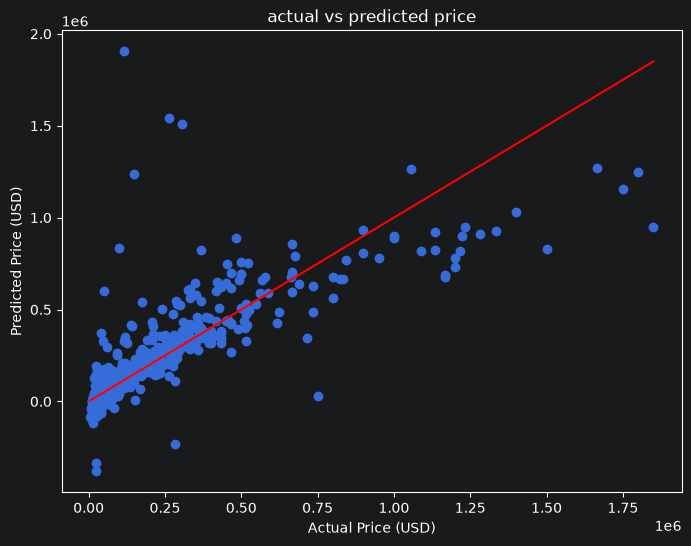

In [41]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
)
plt.xlabel('Actual Price (USD)')
plt.ylabel('Predicted Price (USD)')
plt.title('actual vs predicted price')
plt.show()

## 📌 Analyze the Residuals


In this step, I visualize the residuals (prediction errors) to further evaluate the Linear Regression model.

Ideally, the residuals should be randomly scattered around the zero line. A random pattern suggests that the model has captured the underlying relationship reasonably well, while visible patterns may indicate that the model is missing important information or that a more complex model could perform better.

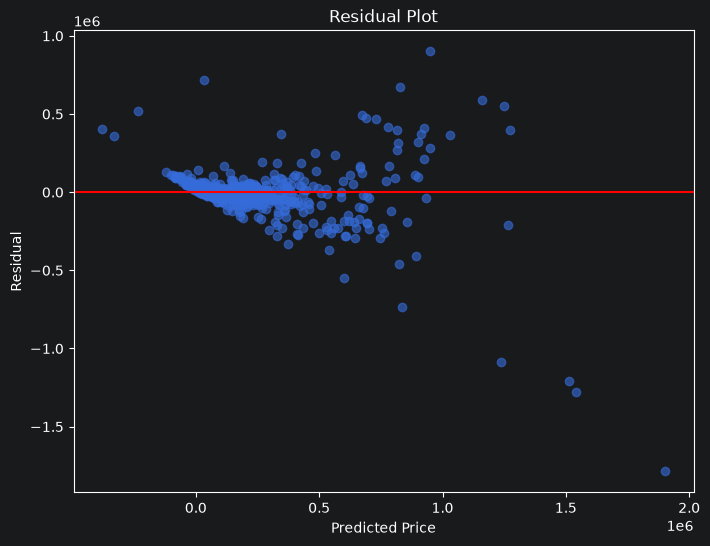

In [22]:
residuals = y_test - y_pred

plt.figure(figsize=(8,6))

plt.scatter(y_pred, residuals, alpha=0.6)

plt.axhline(y=0, color="red")

plt.xlabel("Predicted Price")
plt.ylabel("Residual")

plt.title("Residual Plot")

plt.show()

# 📌 Conclusion

In this section, I built a complete **Linear Regression** workflow without using a Pipeline. The process included data preparation, feature encoding, model training, prediction, and performance evaluation.

Building the workflow step by step helped me better understand how each stage works and how all the components fit together.

In the next section, I will implement the same workflow using **Scikit-learn Pipeline**. This approach makes the code cleaner, more organized, and easier to maintain. Finally, I will compare both implementations and discuss their differences.

# 📌 Building the Same Workflow with a Pipeline

### Why use a Pipeline?

So far, I completed the entire workflow manually, including data preprocessing, feature encoding, model training, and evaluation.

In this section, I will rebuild the same workflow using **Scikit-learn Pipeline**. Pipelines help organize the preprocessing and modeling steps into a single workflow, making the code cleaner, easier to maintain, and less error-prone.

In [23]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression

## 📌 Define Feature Types


Before building the Pipeline, I separate the features based on their data types.

Numerical and categorical features are defined independently so that the Pipeline can automatically apply the appropriate preprocessing steps to each group.

In [24]:
numerical_features = [
    'Area',
    'Room',
    'Parking',
    'Warehouse',
    'Elevator',
]

categorical_features = [
    'Address'
]

## 📌 Build the Preprocessing Pipeline


In this step, I define the preprocessing workflow using a **ColumnTransformer**.

The numerical features are passed directly to the model, while the **Address** feature is transformed using **One-Hot Encoding**. This allows all preprocessing steps to be handled automatically as part of the Pipeline.

In [25]:
new_encoder = OneHotEncoder(
    handle_unknown='ignore',
    drop='first'
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_features),
        ('cat', new_encoder, categorical_features)
    ]
)

## 📌 Prepare the Input and Target Variables


Before building the Pipeline, I define the input features (**X**) and the target variable (**Y**) once again.

These variables will be passed directly into the Pipeline, allowing preprocessing, model training, and prediction to be handled within a single workflow.

In [26]:
X = df[['Area',
        'Room',
        'Parking',
        'Warehouse',
        'Elevator',
        'Address']]
Y = df['Price(USD)']

## 📌 Build the Complete Pipeline


In this step, I first split the dataset into training and testing sets.

Next, I create a **Scikit-learn Pipeline** that combines the preprocessing workflow with the **Linear Regression** model. This approach keeps the entire machine learning workflow in a single, organized structure, making the code easier to read, maintain, and reuse.

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

new_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('regressor', LinearRegression())
    ]
)

## 📌 Train the Pipeline


In this step, I train the entire Pipeline using the training dataset.

With a single `fit()` call, the Pipeline automatically performs all preprocessing steps and then trains the **Linear Regression** model. This is one of the main advantages of using a Pipeline, as it keeps the entire workflow consistent and easy to manage.

In [28]:
new_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](6,)","['Area','Room','Parking','Warehouse','Elevator','Address']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,6
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concaten

## 📌 Access the Model Coefficients


Since the regression model is now part of a Pipeline, I access it through the Pipeline to retrieve its coefficients.

This allows me to interpret the effect of each feature on the predicted house price, just as I did with the manually built model.

In [29]:
new_model.named_steps['regressor'].coef_

array([    2571.14096458,     1853.79028609,   -24341.47005553,
          -2417.51527192,    -6594.00305248,   -61962.11348834,
       -1099990.8972716 ,   -88049.73398266,  -120872.47838397,
         -81950.98624965,  -110146.52665762,   148691.89082796,
        -110666.38095249,  -126026.24063598,   -27703.64138264,
        -184202.60716988,  -105845.52832421,  -178719.85367244,
         223133.12782589,   -32835.4382    ,    92902.79609216,
        -145124.3822854 ,  -156762.93622252,   -91159.02991327,
         -92044.89404251,  -140975.10883163,  -130522.04622757,
        -166663.9458658 ,   -96241.75761633,  -120786.42151103,
         -62817.54994391,  -162796.8191173 ,    18105.75808824,
        -533925.34869472,   -18353.88917064,   -53182.88947443,
         -18783.70867798,  -144270.6929069 ,  -131469.42521508,
          15466.2168745 ,   244217.27502321,   -71584.51108204,
         -84612.94030539,   -31478.66081906,    16332.31276938,
         329780.9039171 ,  -110828.94243

## 📌 Make Predictions with the Pipeline


Now I use the trained Pipeline to predict house prices for the test dataset.

Unlike the manual workflow, all preprocessing steps are automatically applied before the prediction is made. This makes the prediction process simpler, cleaner, and less prone to errors.

In [30]:
y_pred = new_model.predict(X_test)

C:\Users\technobist.ir\Desktop\my_codes\ml jadi\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


## 📌 Evaluate the Pipeline Performance


After generating predictions with the Pipeline, I evaluate its performance using the same metrics as before.

Using identical evaluation metrics makes it possible to compare the Pipeline implementation with the manually built workflow in a fair and consistent way.

In [31]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2  :", r2)

MAE : 75953.28900120096
MSE : 27107638184.101425
RMSE: 164643.97402911965
R2  : 0.613771440107611


# 📌 Final Comparison

Both approaches produce nearly identical results because they use the same dataset and the same **Linear Regression** model.

The main difference lies in the implementation. The Pipeline version provides a cleaner, more organized, and more maintainable workflow by combining preprocessing and model training into a single process.

For small projects, both approaches work well, but for larger and more complex machine learning projects, using a **Pipeline** is generally the preferred solution.

## 🚀 What I Learned

- Data cleaning and preprocessing
- Feature encoding with One-Hot Encoding
- Linear Regression
- Model evaluation (MAE, MSE, RMSE, R²)
- Pipeline and ColumnTransformer
- Comparing manual workflows with Pipeline

---
## 👨‍💻 Author

Created by **Mehdi Ferdosi**

Computer Science Student | Machine Learning Learner

⭐ Thanks for checking out this project!